# 02: Business Model and Unit Economics

**Business question**: Before diagnosing AirAsia's crisis, this notebook builds the vocabulary and the baseline numbers needed to read the rest of the project: how does a low-cost carrier actually make money, what do six years of the group's own revenue and profit history look like, and what do AirAsia's own real Q1-Q2 2026 numbers say about its unit economics right now?

## How a low-cost carrier makes money

Three levers matter more than anything else for an airline like AirAsia:

- **RASK (Revenue per Available Seat Kilometre)**: total revenue divided by total flying capacity. This blends ticket fares and ancillary revenue (baggage, seat selection, meals) into one number.
- **CASK (Cost per Available Seat Kilometre)**: total operating cost divided by the same capacity measure. When CASK exceeds RASK, the airline is losing money on an operating basis.
- **Load factor**: the percentage of available seats actually sold. A high load factor means the airline is filling planes efficiently; a falling one, even with strong fares, signals softer demand or a network mismatch.

## Six years first: the 2025-2026 fuel shock isn't the whole story

The rest of this notebook, and much of this project, zooms into the last few quarters. Before doing that, it's worth seeing the six-year backdrop those quarters sit inside, because the group's revenue base itself has changed shape more than once in that period.

In [1]:
import pandas as pd
from IPython.display import Image

annual = pd.read_csv('../data/processed/annual_financials.csv')
annual[['fiscal_year', 'revenue_rm_m', 'net_profit_loss_rm_m', 'reporting_basis']]

,fiscal_year,revenue_rm_m,net_profit_loss_rm_m,reporting_basis
0,2020,3100.0,-5900.0,whole_group
1,2021,1700.0,-3800.0,whole_group
2,2022,6600.0,-2620.0,whole_group
3,2023,14800.0,508.0,whole_group
4,2024,NaN,NaN,segment_split_begins
5,2025,3390.0,171.0,non_aviation_only


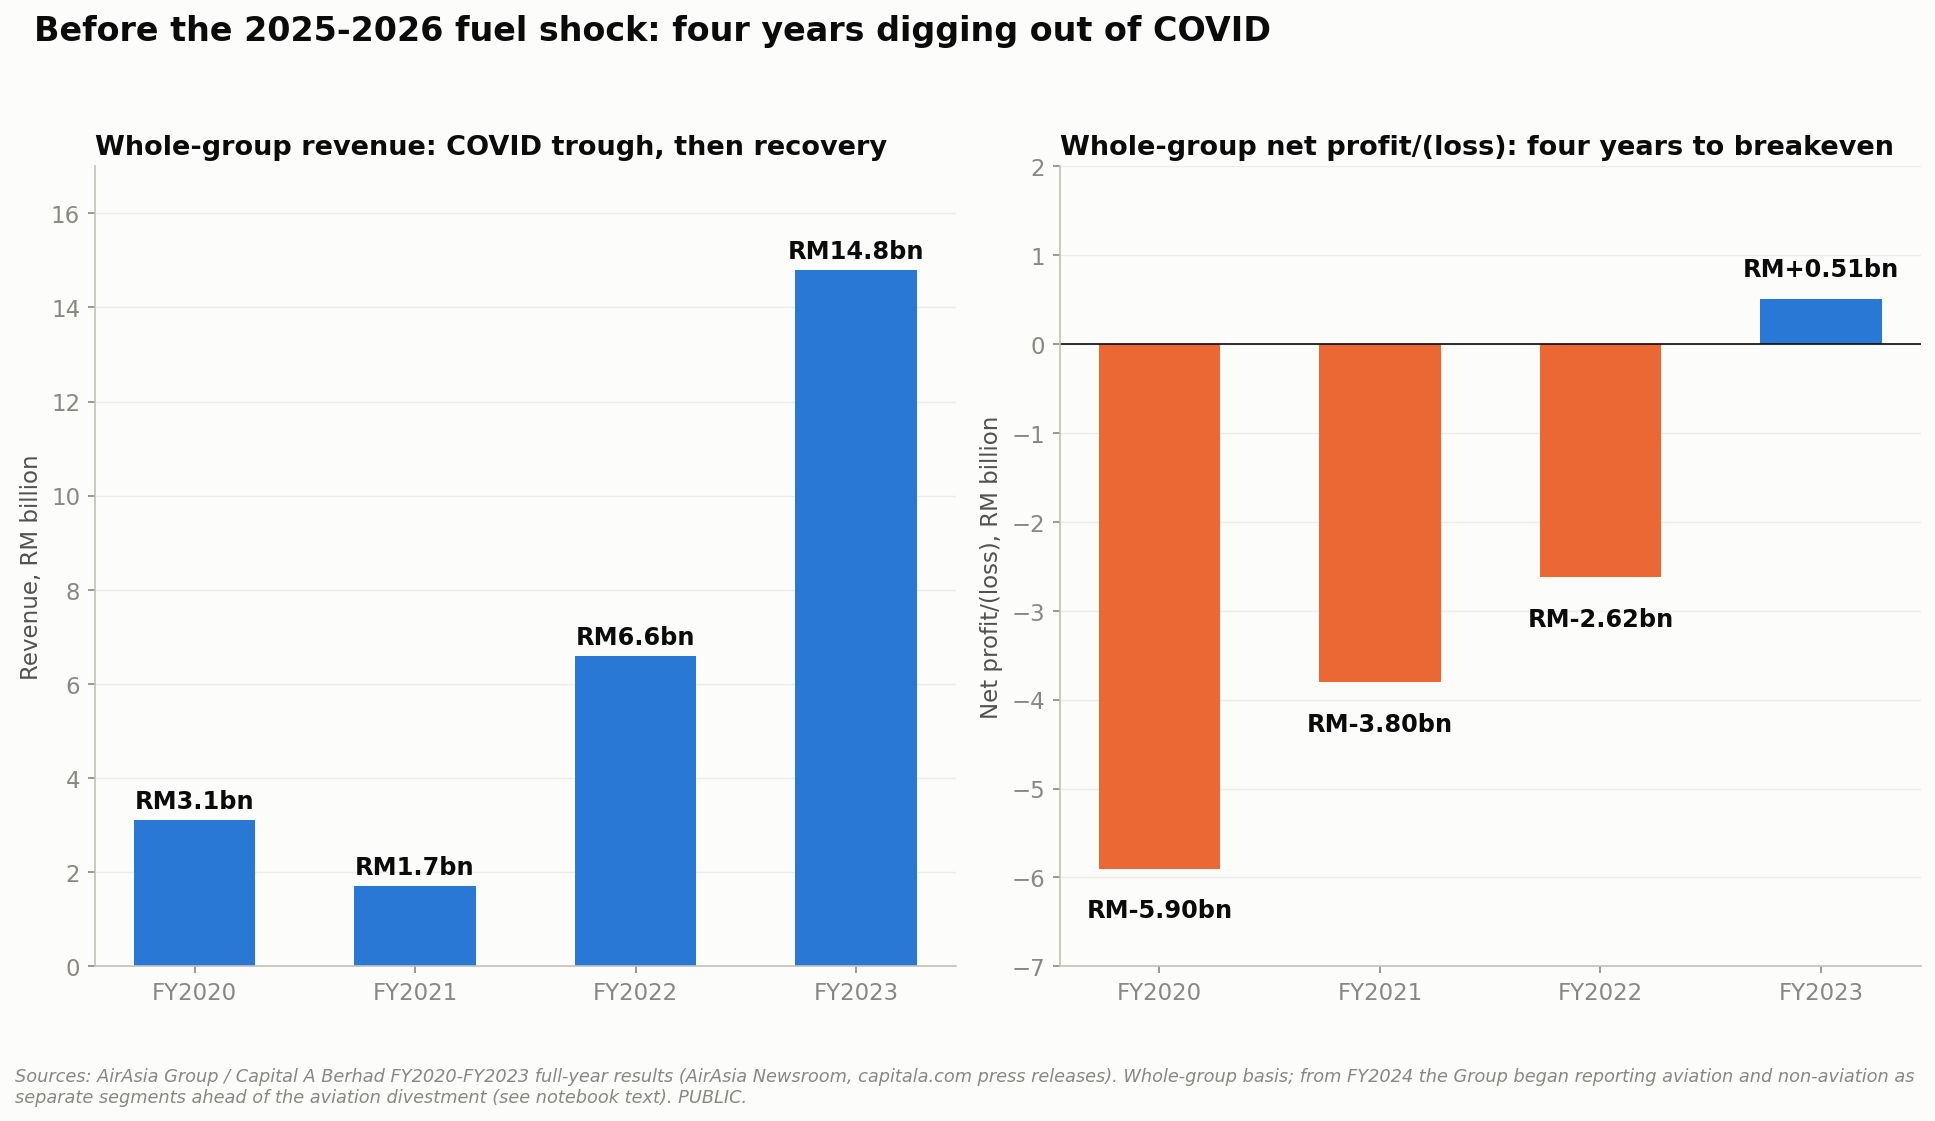

In [2]:
Image(filename='../outputs/figures/02b_five_year_revenue_profit.png')

On a whole-group basis, the numbers tell a clean recovery story across four fiscal years: revenue collapsed from a pre-pandemic scale to **RM1.7 billion at its 2021 trough**, then recovered to **RM14.8 billion by FY2023**, a year that also delivered the group's **first full-year net profit (RM508 million) since the pandemic**. **[PUBLIC]** That took four straight years of losses totalling roughly **RM12.3 billion (FY2020-FY2022 combined)** to get there, a simple sum of the three PUBLIC annual figures above. **[DERIVED]**

The trail goes less clean after that, and the reason why matters for reading this entire project. Starting in **FY2024**, the Group began reporting its aviation business and its non-aviation businesses (Teleport, ADE, AirAsia MOVE, BigPay) as **separate segments** ahead of a planned disposal: FY2024 aviation revenue was **RM19 billion** (EBITDA RM3.2 billion), while non-aviation revenue was **just under RM3.0 billion** (profit after tax RM147 million), but the press release does not state a single consolidated net profit or loss for the year on a comparable basis to FY2020-FY2023. By **FY2025**, the aviation business had been **disposed to AirAsia X Berhad, completing on 3 December 2025**; what remained as "Capital A" for that year was the non-aviation businesses alone, with revenue of **RM3.39 billion** and a one-off gain on the disposal that restored the Group to **positive shareholder equity of RM937 million**. **[PUBLIC]**

That is not a data gap in this project; it is the same entity discontinuity documented in **Notebook 4**, visible a year earlier in the raw financial reporting than in the January 2026 reverse acquisition itself. The group whose unit economics this notebook analyses for 2025-2026 is, legally, a different entity (AirAsia X Berhad, renamed AirAsia Group Berhad) from the one that reported RM14.8 billion in FY2023 revenue. The six-year revenue and profit trend above is real and instructive, but it should be read as the story of the underlying flying business and its economics, not as a single continuous company's income statement.

## AirAsia's own real numbers, Q1-Q2 2026

In [3]:
import pandas as pd
from IPython.display import Image

stats = pd.read_csv('../data/processed/operating_stats.csv')
stats['cask_minus_rask'] = stats['cask'] - stats['rask']
print('CASK minus RASK by quarter (positive = operating loss per ASK):')
stats[['quarter', 'rask', 'cask', 'cask_minus_rask', 'fuel_price']]

CASK minus RASK by quarter (positive = operating loss per ASK):


,quarter,rask,cask,cask_minus_rask,fuel_price
0,1Q2025 (proforma),20.38,19.56,-0.82,101
1,1Q2026,19.54,18.87,-0.67,110
2,2Q2025 (proforma),19.12,18.48,-0.64,95
3,2Q2026,21.28,22.72,1.44,183


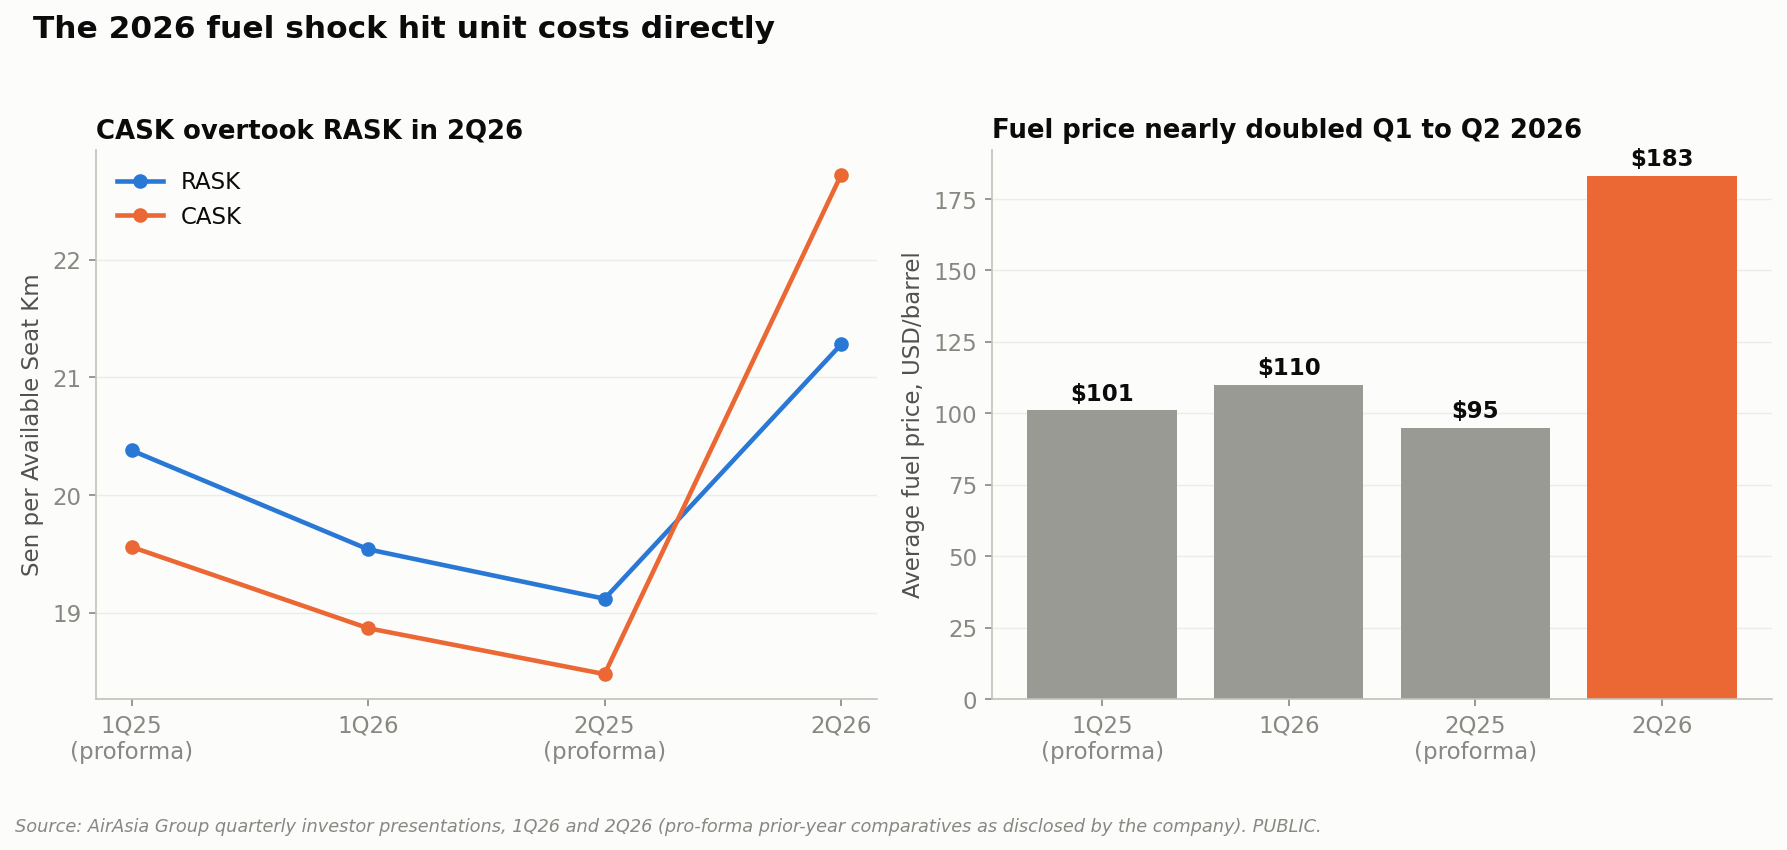

In [4]:
Image(filename='../outputs/figures/02_unit_economics_fuel_shock.png')

This is the clearest single chart in this project. In 1Q26 and both pro-forma comparatives, RASK sat comfortably above CASK, a healthy operating margin per seat kilometre. In 2Q26, CASK jumped to 22.72 sen against RASK of 21.28 sen, an operating loss of roughly 1.44 sen on every available seat kilometre flown. **[PUBLIC, AirAsia Group 1Q26 and 2Q26 investor presentations]**

The right-hand chart shows why: average fuel price jumped from **$110/barrel in 1Q26 to $183/barrel in 2Q26**, a 66% jump within the same year, on top of already being higher than the $95-101/barrel range in the prior-year quarters. This is the same 2026 global oil price shock (the Iran war and Strait of Hormuz disruption) that shows up across commodity markets generally, landing directly on AirAsia's cost base. Note that CASK ex-fuel actually **fell** to 11.02 sen in 2Q26 (down 7% YoY), meaning the airline's non-fuel cost discipline improved; the loss is fuel-driven, not a broader cost-control failure.

## Load factor: softening, but not collapsing

Load factor fell from 86% (1Q25 proforma) to 85% (1Q26), and from 82% (2Q25 proforma) to 80% (2Q26). A 1-2 percentage point year-on-year decline is a real softening signal, worth watching, but it is not the kind of double-digit collapse that would by itself explain a solvency crisis. **[PUBLIC]** Combined with the fuel evidence above, the picture this notebook supports is: demand is softening modestly, but the dominant driver of 2Q26's operating pressure is the external fuel price shock, not a demand collapse.

## Why is load factor softening: fare choice, not falling demand

The company's own 2Q26 investor presentation gives a direct answer this notebook's earlier draft didn't have: **3-month forward bookings were holding at the same level as the prior year, even with fares up 21%**, and **70-80% of bookings continued to be made within 90 days of departure**, which the company reads as customers adapting to the new dynamic fuel-surcharge pricing rather than avoiding AirAsia altogether. **[PUBLIC, AirAsia Group 2Q26 investor presentation]**

Domestic Malaysia is the clearest evidence for this: revenue there fell only 1% year-on-year despite a 13% capacity cut, because a 24-29% fare increase and 19% RASK growth more than offset fewer seats sold. Reading this alongside the softening load factor above, the picture is not "fewer people want to fly AirAsia." It is closer to "AirAsia raised fares hard enough, in response to the fuel shock, that a couple of load-factor points were traded away for meaningfully higher revenue per seat," a deliberate yield-over-volume choice rather than a demand collapse. **[PUBLIC]**

This project cannot independently verify forward-booking data since it isn't published outside the company's own disclosures, so this reading rests on AirAsia's own claim rather than an outside data source (a ticket-price scrape or travel-agent survey, for instance). It is included because it is the most direct evidence available on the demand question, not because it has been cross-checked against an independent source.

## Explain It Simply

Zooming out first: it took AirAsia four straight years of losses, roughly RM12.3 billion combined, to climb back from COVID's RM1.7 billion revenue trough in 2021 to its first profitable full year in 2023. After that, the group's own accounting got more complicated, not because of hidden problems, but because it started splitting itself into pieces (aviation versus the digital/logistics businesses) ahead of eventually selling the aviation piece to its own sister company in 2026, which is the reverse acquisition covered in Notebook 4.

Zooming into the last year specifically: airlines make money by selling more revenue per seat-kilometre flown (RASK) than it costs them to fly that seat-kilometre (CASK). For most of the last year, AirAsia managed this fine. Then in the second quarter of 2026, the price of jet fuel nearly doubled because of a global oil crisis, and suddenly the cost side outran the revenue side. The airline actually got better at controlling its non-fuel costs over the same period, cutting them by 7%, so this isn't a story of AirAsia losing its grip on spending. It's a story of an external oil shock hitting at a bad time, layered on top of a company still only a few years removed from a genuine near-death experience.

## Glossary

- **RASK / CASK**: Revenue and Cost per Available Seat Kilometre, the standard airline unit-economics measures.
- **ASK**: Available Seat Kilometres, total flying capacity (seats multiplied by distance flown).
- **Load factor**: the share of available seats actually sold.
- **Pro-forma**: a restated figure showing what results would have looked like under a different structure, here, as if the January 2026 consolidation had applied a year earlier, for a fairer year-on-year comparison.
- **PAT (Profit After Tax)** and **NOP (Net Operating Profit)**: two different bottom-line measures Capital A has used across its FY2020-FY2025 reporting; NOP is a Capital A-specific operating profit measure that excludes certain one-off items, which is why it is not always directly comparable to the plain net profit/loss figures used in earlier years.

## Why Is This Happening?

**Why does a fuel price swing hit a low-cost carrier harder than a full-service one?** Low-cost carriers run thinner margins per seat by design, competing on price, so they have less cushion to absorb a cost shock before it turns an operating profit into an operating loss. AirAsia's own data shows this precisely: CASK ex-fuel actually improved, but the fuel line alone was enough to flip the total unit-cost picture. A full-service carrier with higher RASK to begin with (from business/first class revenue, cargo, and alliance revenue-sharing) has more room to absorb the same fuel shock before crossing into a loss.

---
**Sources**: [AirAsia Newsroom: AirAsia Group Berhad Fourth Quarter and Full Year 2020 Financial Results](https://newsroom.airasia.com/news/airasia-group-berhad-4q2020-full-year-financial-results); [AirAsia Newsroom: Capital A 4Q2021 Financial Results](https://newsroom.airasia.com/news/capital-a-4q2021-financial-results); [AirAsia Newsroom: Capital A 4Q2022 Financial Results](https://newsroom.airasia.com/news/capital-a-4q2022-financial-results); [The Star: Capital A back in the black in FY2022, net loss of RM2.62 billion cited for the prior year](https://www.thestar.com.my/business/business-news/2024/02/29/capital-a-back-in-the-black-with-rm83698mil-net-profit-in-fy23); [AirAsia Newsroom: Capital A Financial Results Fourth Quarter 2023 and Full Financial Year 2023](https://newsroom.airasia.com/news/capital-a-financial-results-fourth-quarter-2023-and-full-financial-year-2023); Capital A Fourth Quarter 2024 press release (capitala.com/misc/press-release-4Q24.pdf); Capital A Fourth Quarter 2025 and Full Financial Year 2025 press release (capitala.com/misc/press-release-4Q25.pdf); AirAsia Group Berhad, 1Q26 and 2Q26 investor presentation slides (investor.airasiagroup.com), operating statistics tables including pro-forma prior-year comparatives as disclosed by the company. All figures **PUBLIC**, extracted directly from the company's own press releases and investor presentation PDFs.